In [33]:
import pandas as pd
import seaborn as sns

from scipy.stats import kruskal
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statannotations.Annotator import Annotator

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [34]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\species

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\species


In [35]:
## qzv 파일 Qiime2View에 넣고 'Download raw data as TSV' 로 다운받은 후 파일명만 바꿔서 사용
df_observed = pd.read_csv('alpha_diversity_results.csv', usecols=['SampleID', 'Group', 'Observed'])
df_shannon = pd.read_csv('alpha_diversity_results.csv', usecols=['SampleID', 'Group', 'Shannon'])
df_simpson = pd.read_csv('alpha_diversity_results.csv', usecols=['SampleID', 'Group', 'Simpson'])

print(df_observed.head(3))
print(df_shannon.head(3))
print(df_simpson.head(3))

  SampleID  Observed    Group
0   C01-2w      7568  Control
1   C02-2w      6474  Control
2   C03-2w      7188  Control
  SampleID   Shannon    Group
0   C01-2w  4.629627  Control
1   C02-2w  4.189164  Control
2   C03-2w  4.387162  Control
  SampleID   Simpson    Group
0   C01-2w  0.905661  Control
1   C02-2w  0.848813  Control
2   C03-2w  0.885124  Control


In [36]:
## Group 종류 확인
print(df_observed.Group.unique())
print(df_shannon.Group.unique())
print(df_simpson.Group.unique())

['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']


Statistic: 10.14
P-value: 1.45e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.448e-03 Stat=1.014e+01


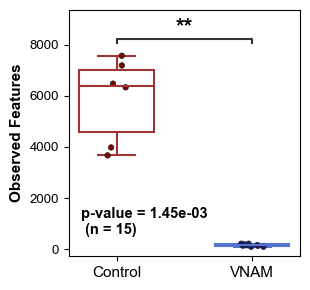

In [37]:
## Observed Features


data = df_observed
feat = data.columns[1]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['Observed']  #Edit
VNAM = data[data['Group'] == 'VNAM']['Observed']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']
d_colors = ['maroon', 'midnightblue']

plt.figure(figsize=(3.2, 3))

ax = sns.boxplot(data=data, x='Group', y=feat, order=orders, palette=palette, width=0.55, fliersize=0, linewidth=1.5)

box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
box_patches = box_patches[:len(orders)]

lines = ax.lines
nbox = len(box_patches)
k = (len(lines) // nbox) if nbox else 0

for i, pch in enumerate(box_patches):
    fc = pch.get_facecolor()
    pch.set_facecolor((0, 0, 0, 0))
    pch.set_edgecolor(fc)
    pch.set_linewidth(1.5)

    if k:
        for ln in lines[i*k:(i+1)*k]:
            ln.set_color(fc)
            ln.set_linewidth(1.5)

sns.stripplot(data=data, x='Group', y=feat, jitter=True, edgecolor='gray', linewidth=0.5, palette=d_colors, order=orders, size=4, zorder = 2)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data, x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside', fontsize=16)
annot.apply_test()
annot.annotate()

# ns 제외한 유의표시만 bold 처리
for txt in ax.texts:
    s = txt.get_text().strip()
    if s in {'*', '**', '***', '****'}:
            txt.set_fontweight('bold')


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=11)
#plt.ylim(-10, )
plt.ylabel('Observed Features', fontsize=11, fontweight='bold')
plt.xlabel('')
#plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
leg = plt.legend([], [], title=label, loc='lower left', frameon=False, title_fontsize=10.5)  #Edit
leg.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig('observed.png', dpi=500, bbox_inches='tight')

Statistic: 10.12
P-value: 1.46e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.463e-03 Stat=1.012e+01


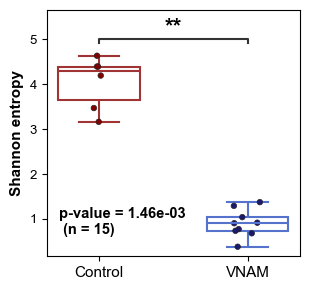

In [39]:
## Shannon Entropy


data = df_shannon
feat = data.columns[1]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['Shannon']  #Edit
VNAM = data[data['Group'] == 'VNAM']['Shannon']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']
d_colors = ['maroon', 'midnightblue']

plt.figure(figsize=(3.2, 3))

ax = sns.boxplot(data=data, x='Group', y=feat, order=orders, palette=palette, width=0.55, fliersize=0, linewidth=1.5)

box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
box_patches = box_patches[:len(orders)]

lines = ax.lines
nbox = len(box_patches)
k = (len(lines) // nbox) if nbox else 0

for i, pch in enumerate(box_patches):
    fc = pch.get_facecolor()
    pch.set_facecolor((0, 0, 0, 0))
    pch.set_edgecolor(fc)
    pch.set_linewidth(1.5)

    if k:
        for ln in lines[i*k:(i+1)*k]:
            ln.set_color(fc)
            ln.set_linewidth(1.5)

sns.stripplot(data=data, x='Group', y=feat, jitter=True, edgecolor='gray', linewidth=0.5, palette=d_colors, order=orders, size=4, zorder = 2)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data, x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside', fontsize=16)
annot.apply_test()
annot.annotate()

# ns 제외한 유의표시만 bold 처리
for txt in ax.texts:
    s = txt.get_text().strip()
    if s in {'*', '**', '***', '****'}:
            txt.set_fontweight('bold')


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=11)
#plt.ylim(0, 175)
plt.ylabel('Shannon entropy', fontsize=11, fontweight='bold')
plt.xlabel('')
#plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
leg = plt.legend([], [], title=label, loc='lower left', frameon=False, title_fontsize=10.5)  #Edit
leg.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig('shannon.png', dpi=500, bbox_inches='tight')

Statistic: 10.12
P-value: 1.46e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.463e-03 Stat=1.012e+01


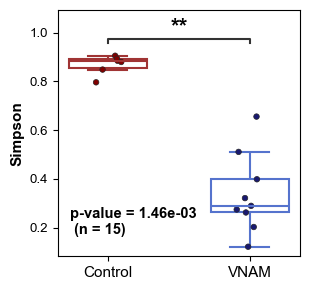

In [40]:
## Simpson


data = df_simpson
feat = data.columns[1]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['Simpson']  #Edit
VNAM = data[data['Group'] == 'VNAM']['Simpson']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']
d_colors = ['maroon', 'midnightblue']

plt.figure(figsize=(3.2, 3))

ax = sns.boxplot(data=data, x='Group', y=feat, order=orders, palette=palette, width=0.55, fliersize=0, linewidth=1.5)

box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
box_patches = box_patches[:len(orders)]

lines = ax.lines
nbox = len(box_patches)
k = (len(lines) // nbox) if nbox else 0

for i, pch in enumerate(box_patches):
    fc = pch.get_facecolor()
    pch.set_facecolor((0, 0, 0, 0))
    pch.set_edgecolor(fc)
    pch.set_linewidth(1.5)

    if k:
        for ln in lines[i*k:(i+1)*k]:
            ln.set_color(fc)
            ln.set_linewidth(1.5)

sns.stripplot(data=data, x='Group', y=feat, jitter=True, edgecolor='gray', linewidth=0.5, palette=d_colors, order=orders, size=4, zorder = 2)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data, x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside', fontsize=16)
annot.apply_test()
annot.annotate()

# ns 제외한 유의표시만 bold 처리
for txt in ax.texts:
    s = txt.get_text().strip()
    if s in {'*', '**', '***', '****'}:
            txt.set_fontweight('bold')


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=11)
#plt.ylim(0, 175)
plt.ylabel('Simpson', fontsize=11, fontweight='bold')
plt.xlabel('')
#plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
leg = plt.legend([], [], title=label, loc='lower left', frameon=False, title_fontsize=10.5)  #Edit
leg.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig('simpson.png', dpi=500, bbox_inches='tight')